# Tutorial 13: Denoising AutoEncoders

### 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Load and Normalize Data

In [2]:
# Load the MNIST dataset and normalize
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

# DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

### 3. Define the Noise Function

In [3]:
# Function to add random noise and clip values between 0 and 1
def add_noise(images, noise_factor=0.5):
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

### 4. Implement the Denoising Autoencoder

In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # Encoder[cite: 1]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), # Conv2D 32
            nn.MaxPool2d(2, 2),                         # Max Pooling
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),# Conv2D 64
            nn.MaxPool2d(2, 2)                          # Max Pooling
        )
        # Decoder[cite: 1]
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),                # UpSampling
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),                # UpSampling
            nn.Conv2d(32, 1, 3, padding=1), nn.Sigmoid()# Final reconstruction
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

dae_model = DenoisingAutoencoder().to(device)

### 5. Implmenet the Deep Autoencoder (Task 1)

In [5]:
class DeepAutoencoder(nn.Module):
    def __init__(self):
        super(DeepAutoencoder, self).__init__()
        # Deep stack of linear layers
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64) # Compressed latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 28*28), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 1, 28, 28)

deep_ae_model = DeepAutoencoder().to(device)

### 6. Implement the Variational Autoencoder (VAE) (Task 2)

In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae_model = VAE().to(device)

### 7. Loss fucntions and Traininf loop

In [7]:
def vae_loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (BCE + KLD) / x.size(0)

def train_epoch(model, loader, optimizer, mode='standard'):
    model.train()
    running_loss = 0.0
    for data, _ in loader:
        data = data.to(device)
        optimizer.zero_grad()

        if mode == 'vae':
            recon, mu, logvar = model(data)
            loss = vae_loss_fn(recon, data, mu, logvar)
        elif mode == 'denoising':
            noisy_data = add_noise(data).to(device)
            output = model(noisy_data)
            loss = F.binary_cross_entropy(output, data)
        else: # Deep AE
            output = model(data)
            loss = F.binary_cross_entropy(output, data)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

# Initialize models and optimizers
dae = DenoisingAutoencoder().to(device)
deep_ae = DeepAutoencoder().to(device)
vae = VAE().to(device)

opt_dae = optim.Adam(dae.parameters())
opt_deep = optim.Adam(deep_ae.parameters())
opt_vae = optim.Adam(vae.parameters())

dae_hist, deep_hist, vae_hist = [], [], []

### 8. Training Execution

In [9]:
def vae_loss_fn(recon_x, x, mu, logvar):
    # Flatten x to match recon_x's shape for BCE calculation
    x_flat = x.view(-1, 784)
    BCE = F.binary_cross_entropy(recon_x, x_flat, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (BCE + KLD) / x.size(0)

epochs = 10
for epoch in range(epochs):
    l_dae = train_epoch(dae, train_loader, opt_dae, mode='denoising')
    l_deep = train_epoch(deep_ae, train_loader, opt_deep, mode='standard')
    l_vae = train_epoch(vae, train_loader, opt_vae, mode='vae')

    print(f"Epoch {epoch+1}: DAE Loss: {l_dae:.4f} | Deep Loss: {l_deep:.4f} | VAE Loss: {l_vae:.4f}")

Epoch 1: DAE Loss: 0.1115 | Deep Loss: 0.1445 | VAE Loss: 166.1870
Epoch 2: DAE Loss: 0.1064 | Deep Loss: 0.1281 | VAE Loss: 121.6704
Epoch 3: DAE Loss: 0.1035 | Deep Loss: 0.1190 | VAE Loss: 114.9269
Epoch 4: DAE Loss: 0.1015 | Deep Loss: 0.1115 | VAE Loss: 111.8669
Epoch 5: DAE Loss: 0.1000 | Deep Loss: 0.1063 | VAE Loss: 110.0903
Epoch 6: DAE Loss: 0.0990 | Deep Loss: 0.1022 | VAE Loss: 108.8889
Epoch 7: DAE Loss: 0.0983 | Deep Loss: 0.0993 | VAE Loss: 108.0267
Epoch 8: DAE Loss: 0.0976 | Deep Loss: 0.0969 | VAE Loss: 107.3656
Epoch 9: DAE Loss: 0.0971 | Deep Loss: 0.0948 | VAE Loss: 106.8702
Epoch 10: DAE Loss: 0.0966 | Deep Loss: 0.0931 | VAE Loss: 106.3762


### 10. Visualize Results

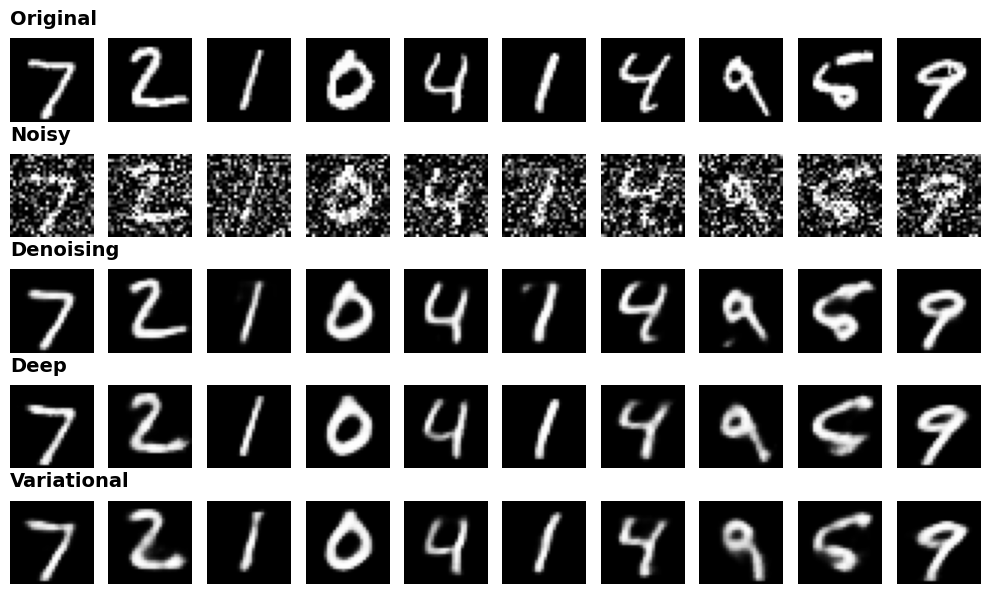

In [26]:
dae.eval(); deep_ae.eval(); vae.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)
    noisy = add_noise(data)
    dae_res = dae(noisy).cpu()
    deep_res = deep_ae(data).cpu()
    vae_res, _, _ = vae(data)
    vae_res = vae_res.cpu()
    data, noisy = data.cpu(), noisy.cpu()

n = 10
fig, axes = plt.subplots(5, n, figsize=(10, 6))
row_names = ['Original', 'Noisy', 'Denoising', 'Deep', 'Variational']
image_sets = [data, noisy, dae_res, deep_res, vae_res]

for r in range(5):
    for c in range(n):
        ax = axes[r, c]
        ax.imshow(image_sets[r][c].view(28, 28), cmap='gray')
        ax.axis('off')
        if c == 0:
            ax.set_title(row_names[r], loc='left', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()